<a href="https://colab.research.google.com/github/tasneemsk500/Basic_Instagram_Page_Clone/blob/main/Tasneem_Shahnewaz_Khan_A4_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A4 - K-Means Clustering
# Your Name: Tasneem Shahnewaz Khan
# CAP4611-26SummerC001
## Also make sure to change the file name based on the requirement and give us the edit permission

## A. Load Data and Perform Basic EDA [5 pts]

### I. Import the necessary libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

### II. Import the data into a dataframe and show the count of rows and columns. (1 pt)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/A4 KMeans Clustering/hrdata3-1.csv")
print(df.shape) #print the shape

(12977, 7)


### III. Show the top 5 and last 5 rows. (1 pt)

In [ ]:
print(df.head(5)) #the top 5 rows

   enrollee_id  city_development_index  experience  company_size  \
0        29725                   0.776          15             2   
1          666                   0.767          21             2   
2        28806                   0.920           5             2   
3          402                   0.762          13             0   
4        27107                   0.920           7             2   

   last_new_job  training_hours  target  
0             5              47       0  
1             4               8       0  
2             1              24       0  
3             5              18       1  
4             1              46       1  


In [ ]:
print(df.tail(5)) #the bottom 5 rows

       enrollee_id  city_development_index  experience  company_size  \
12972          251                   0.920           9             2   
12973        32313                   0.920          10             3   
12974        29754                   0.920           7             1   
12975        24576                   0.920          21             2   
12976         5756                   0.802           0             4   

       last_new_job  training_hours  target  
12972             1              36       1  
12973             3              23       0  
12974             1              25       0  
12975             4              44       0  
12976             2              97       0  


### IV. Check whether there are any null values in any column.

In [ ]:
nulls = df.isnull().sum().to_frame('nulls') #sum up nulls and make a df
# print(nulls)
nulls.sort_values("nulls", inplace = True, ascending = False) #sort it by descending order

for index, row in nulls.iterrows(): #print it in well formatted way
 print(index, row['nulls'])

enrollee_id 0
city_development_index 0
experience 0
company_size 0
last_new_job 0
training_hours 0
target 0


### V. Check whether all the columns are numeric. If not, convert them to numeric before proceeding.

In [ ]:
#check if all are numeric types just to make sure
print(df.dtypes)

enrollee_id                 int64
city_development_index    float64
experience                  int64
company_size                int64
last_new_job                int64
training_hours              int64
target                      int64
dtype: object


From above we can see that all the data types are either int or float. Thus, it's already in its numeric form

### VI. Plot a heatmap of the correlations to get more insight into the data.

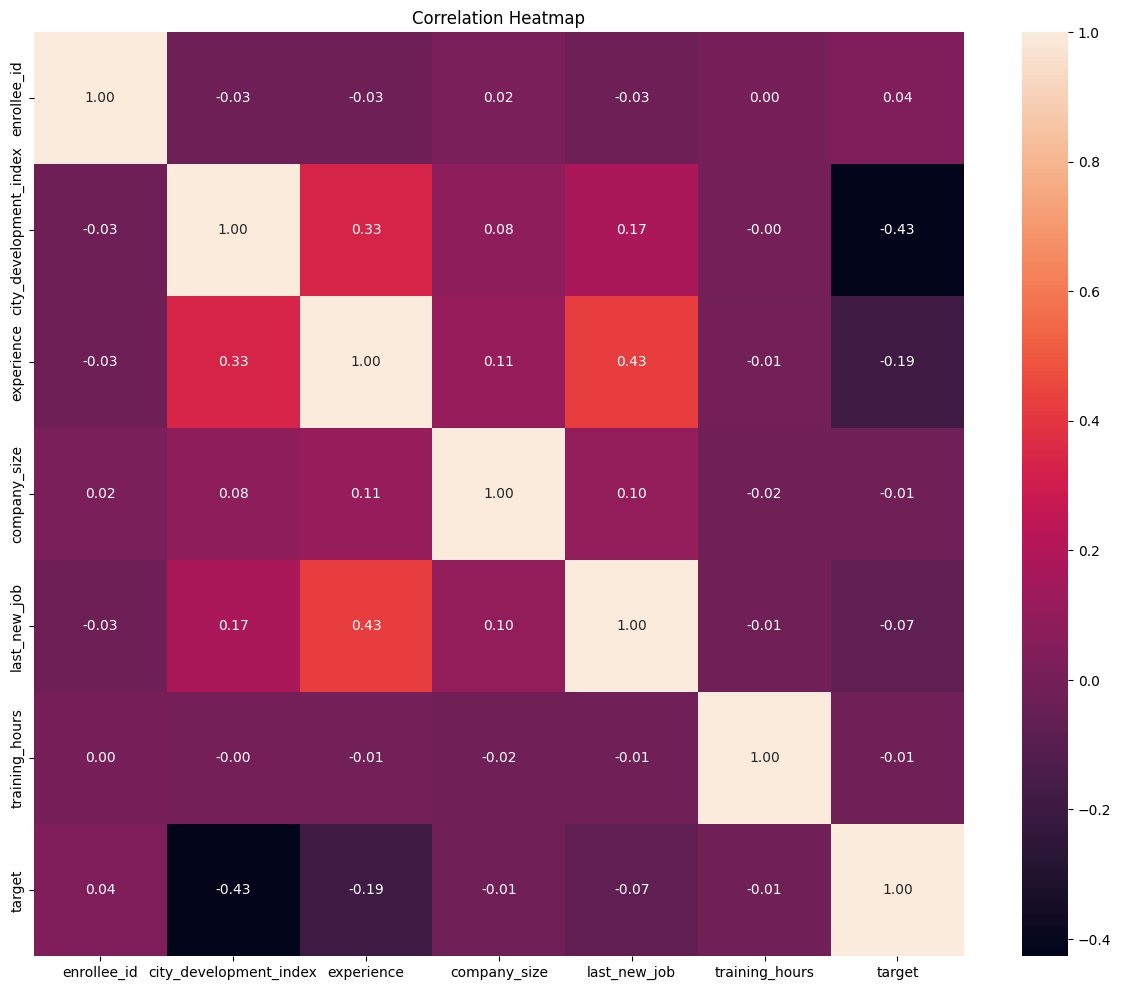

In [ ]:
#Create a numeric feature variable
num_features = df.select_dtypes(include = [np.number])
num_features.columns
correlation = num_features.corr()

#Plot the heatmap
plt.figure(figsize = (15, 12))
sns.heatmap(correlation, annot=True, xticklabels=num_features.columns, yticklabels=num_features.columns, fmt='.2f') #use at least 2 decimal value to see the correlations

plt.title('Correlation Heatmap')

plt.show()

## B. Feature Selection and Pre-processing [4 pts]

### I. Put all the data from the dataframe into X, except the enrollee_id and target columns. (1.5 pts)

In [ ]:
X = df.drop(columns=['enrollee_id', 'target'])

### II. Perform feature scaling on the data of X with StandardScaler and show some sample data from X after scaling. (Use the technique shown in the second answer from this post: https://stackoverflow.com/questions/44552031/sklearnstandardscaler-can-i-inverse-the-standardscaler-for-the-model-output) (2.5 pts)

In [ ]:
#from the stackoverflow technique
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# scaled = scaler.transform(data)
# print(scaled)

# convert it to dataframe from numpy
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

# for inverse transformation
# inversed = scaler.inverse_transform(scaled)
# print(inversed)

   city_development_index  experience  company_size  last_new_job  \
0               -0.503422    0.633957     -0.574723      1.690762   
1               -0.578413    1.546009     -0.574723      1.081137   
2                0.696434   -0.886130     -0.574723     -0.747739   
3               -0.620075    0.329940     -1.488268      1.690762   
4                0.696434   -0.582112     -0.574723     -0.747739   

   training_hours  
0       -0.308396  
1       -0.951805  
2       -0.687842  
3       -0.786828  
4       -0.324894  


## C. K-Means Clustering [26 pts]

### I. Import the relevant library for K-Means and perform K-Means on X (already scaled). Use random_state = 47 and k-means++ for the initial centroids.

In [ ]:
#import library
from sklearn.cluster import KMeans
#perform the K-Means
kmeans = KMeans(n_clusters = 2, init = "k-means++", random_state = 47) #init = "k-means++" will pick the initial centroids smartly instead of randomly
kmeans.fit(X_scaled_df)

KMeans(n_clusters=2, random_state=47)

### II. Show the cluster centers as-is, then inverse the scaling and show the centers again. In a markdown cell, explain the centers, relating them to the columns of the dataset.

In [ ]:
#clusters centers
cluster_cntrs = kmeans.cluster_centers_  #can be used to see the centers of the cluster. (As the previus example we had k = 6, we got 6 centroids)
# print(cluster_cntrs)
#print the centers in dataframe
print(pd.DataFrame(cluster_cntrs, columns=X.columns))

   city_development_index  experience  company_size  last_new_job  \
0                0.445145    0.897729      0.212325      0.766876   
1               -0.319265   -0.643865     -0.152283     -0.550016   

   training_hours  
0       -0.016533  
1        0.011858  


In [ ]:
#Using the inverse technique from BII
cluster_cntrs_inversed = scaler.inverse_transform(cluster_cntrs)

# convert it to dataframe from numpy
cluster_cntrs_inversed_df = pd.DataFrame(cluster_cntrs_inversed, columns=X.columns)

#display
print(cluster_cntrs_inversed_df)

   city_development_index  experience  company_size  last_new_job  \
0                0.889842   16.735240      3.723063      3.484502   
1                0.798101    6.593754      2.924838      1.324335   

   training_hours  
0       64.691144  
1       66.412068  


From the above dataset, we can observe that candidates with cluster number 0 have around 17 years of experience at a company size of roughly 3.7 and 3.5 years since their last job change.

The candidates with cluster number 1 have around 6.6 years of experience at a company size of roughly 3.0 and 1.3 years since their last job change.

The training hours in this case is almost similar with 65 ≈ 66 so this isn't a suitable feature for clustering.

### III. Show the distance matrix.

In [ ]:
kmeans.transform(X_scaled_df)  #distance matrix (how far each x is from its center)

array([[1.58982637, 2.63985755],
       [1.74953576, 2.9377658 ],
       [2.57088589, 1.34069649],
       ...,
       [2.55401651, 1.52129339],
       [1.14810342, 2.96698862],
       [2.85066128, 1.29273902]])

### IV. Show the labels.

In [ ]:
#from webcourse example
identified_clusters = kmeans.labels_ #will give label to the each instance in x
identified_clusters

array([0, 0, 1, ..., 1, 0, 1], dtype=int32)

### V. Add a new column to your dataframe called cluster_label and assign the cluster label for each instance based on the K-Means result.

In [ ]:
df['cluster_label'] = kmeans.labels_  #add a new column to the dataframe to show the cluster for each instance
df

,enrollee_id,city_development_index,experience,company_size,last_new_job,training_hours,target,cluster_label
0,29725,0.776,15,2,5,47,0,0
1,666,0.767,21,2,4,8,0,0
2,28806,0.920,5,2,1,24,0,1
3,402,0.762,13,0,5,18,1,0
4,27107,0.920,7,2,1,46,1,1
...,...,...,...,...,...,...,...,...
12972,251,0.920,9,2,1,36,1,1
12973,32313,0.920,10,3,3,23,0,0
12974,29754,0.920,7,1,1,25,0,1
12975,24576,0.920,21,2,4,44,0,0


### VI. Add a column target_int that stores the integer version of the target column (e.g. 1.0 → 1, 0.0 → 0).

In [ ]:
#convert the values in the target column to int values
df['target_int'] = df['target'].astype(int)

### VII. Show the top 5 rows of the dataframe to confirm the two new columns have the correct values.

In [ ]:
print(df.head(5))

   enrollee_id  city_development_index  experience  company_size  \
0        29725                   0.776          15             2   
1          666                   0.767          21             2   
2        28806                   0.920           5             2   
3          402                   0.762          13             0   
4        27107                   0.920           7             2   

   last_new_job  training_hours  target  cluster_label  target_int  
0             5              47       0              0           0  
1             4               8       0              0           0  
2             1              24       0              1           0  
3             5              18       1              0           1  
4             1              46       1              1           1  


### VIII. Print the confusion matrix comparing target_int and cluster_label, show the classification report, and show the total number of misclassifications.

In [ ]:
#import library
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df['target_int'], df['cluster_label']))
print(classification_report(df['target_int'], df['cluster_label']))


[[4873 5822]
 [ 535 1747]]
              precision    recall  f1-score   support

           0       0.90      0.46      0.61     10695
           1       0.23      0.77      0.35      2282

    accuracy                           0.51     12977
   macro avg       0.57      0.61      0.48     12977
weighted avg       0.78      0.51      0.56     12977



In [ ]:
#misclassification
missclassified = (df['target_int'] != df['cluster_label']).sum()
print("Misclassifications: ", missclassified)

Misclassifications:  6357


### IX. In a markdown cell, discuss the numbers from part VIII and share your thoughts.

It's unknown if cluster 0 and 1 actually mapped to our target value.

target with cluster 0 has a high precision of 0.90 and low recall of 0.46. If the algorithm predicted something positive, it'll predict 90% of the time positive. However, with low recall, it found actual positives only 46% of the time. It missed almost half of the cases and clustered them to the other cluster group instead.

On the other hand, target with cluster 1 has low precision of 0.23 and high recall of 0.77. The model predicted correctly for cluster 1 for around 23% of the time which is less than half. With a higher recall, the K-means algorithm found the true positives 77% of the time.

The accuracy is in this matrix is 0.51 with misclassification rate of 6357. The accuracy is almost half which is like a 50-50 chance. This does not give us the certainty. The misclassification count of 6357 out of 12976. That is almost half percentage with 50-50 chance.

Cluster 0 with a high precision avoids a lot of false alarms while cluster 1 with high recall avoids a lot of missed cases.

These weak scores happened mostly because the algorithm tried to cluster into groups based on the similarity it found in their numbers. It cannot distinguish between the people who would leave or not but it found other similiarities.

### X. Show the inertia of the clustering.

In [ ]:
inertia_clustering = kmeans.inertia_
inertia_clustering

49643.91553358666

### XI. In a markdown cell, explain what the elbow method is and its purpose in the context of K-Means clustering.

To find the optimal value of clusters, we use the elbow method
as described below in the following steps:
1. Execute the K-means clustering on a given dataset for
different K values (e.g., ranging from 1-10).
2. For each value of K, calculate the WCSS value.
3. Plots a graph/curve between WCSS values and the
respective number of clusters K.
4. The sharp point of bend or a point(looking like an elbow
joint) of the plot like an arm, will be considered as the
best/optimal value of K

### XII. Plot the inertia for different numbers of clusters from 2 to 20.

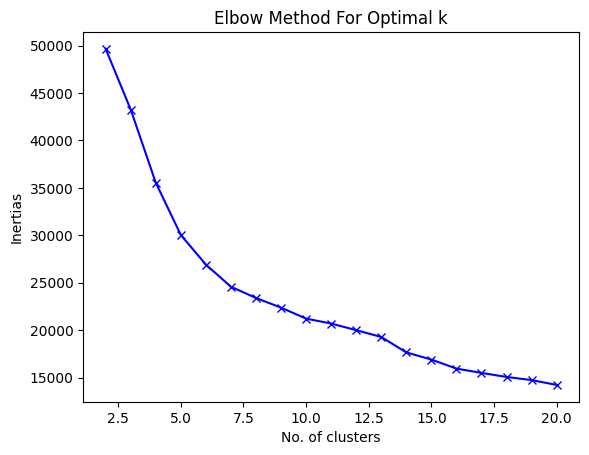

In [ ]:
#from webcourse
# Elbow curve to find optimal K
# cost = []
inertias = []
K = range(2,21) #from 2 to 20
for num_clusters in list(K):
    km = KMeans(n_clusters=num_clusters, init='k-means++', random_state=47) # n_init is the number of times to run The final results will be the best output of n_init consecutive runs in terms of cost.
    km.fit(X_scaled_df)
    inertias.append(km.inertia_)

plt.plot(K, inertias, 'bx-')
plt.xlabel('No. of clusters')
# plt.ylabel('Cost')
plt.ylabel('Inertias')
plt.title('Elbow Method For Optimal k')
plt.show()

### XIII. Show a scatter plot of training hours against experience, with points colored by the two cluster labels. In a markdown cell, share your thoughts on this plot.

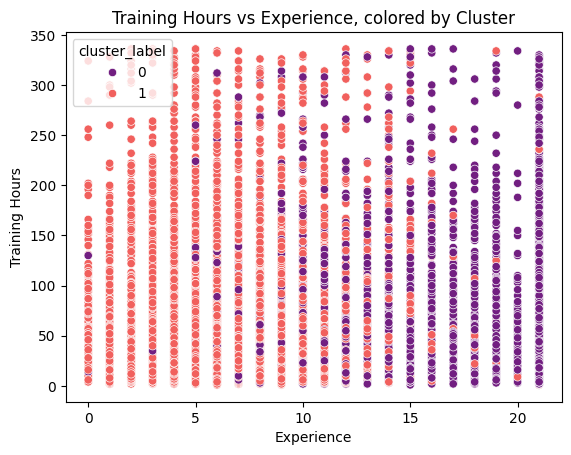

In [ ]:
# plt.scatter(df['experience'], df['training_hours'], c=df['cluster_label'])
sns.scatterplot(data=df, x="experience", y="training_hours", hue="cluster_label", palette="magma")
plt.xlabel('Experience')
plt.ylabel('Training Hours')
plt.title('Training Hours vs Experience, colored by Cluster')
plt.show()

There's a lot of overlapping points beween training hours and experience at around 9 to 15 along x-axis. Thus it might not be a suitable relation to work on.

### XIV. Show a scatter plot of any other two attributes you are interested in, similar to part XIII, and add your thoughts in a markdown cell.

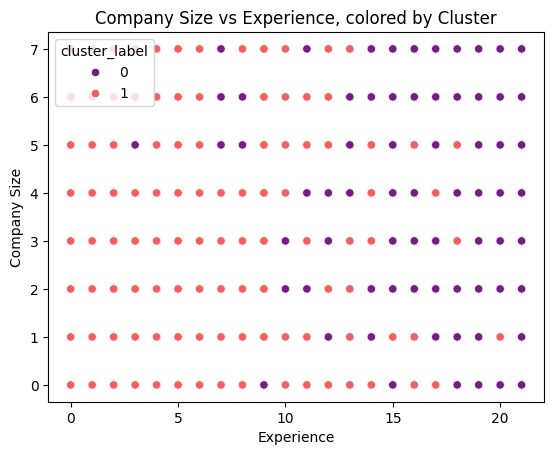

In [ ]:
# plt.scatter(df['experience'], df['company_size'], c=df['cluster_label'])
sns.scatterplot(data=df, x="experience", y="company_size", hue="cluster_label", palette="magma")
plt.xlabel('Experience')
plt.ylabel('Company Size')
plt.title('Company Size vs Experience, colored by Cluster')
plt.show()

There's a clear distintion between the experience years and company size. With increasing experience years, the company size is larger.

## D. Agglomerative Clustering [15 pts]

### Helpful resource: https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/

### I. Plot a dendrogram (use a relatively large figure size).

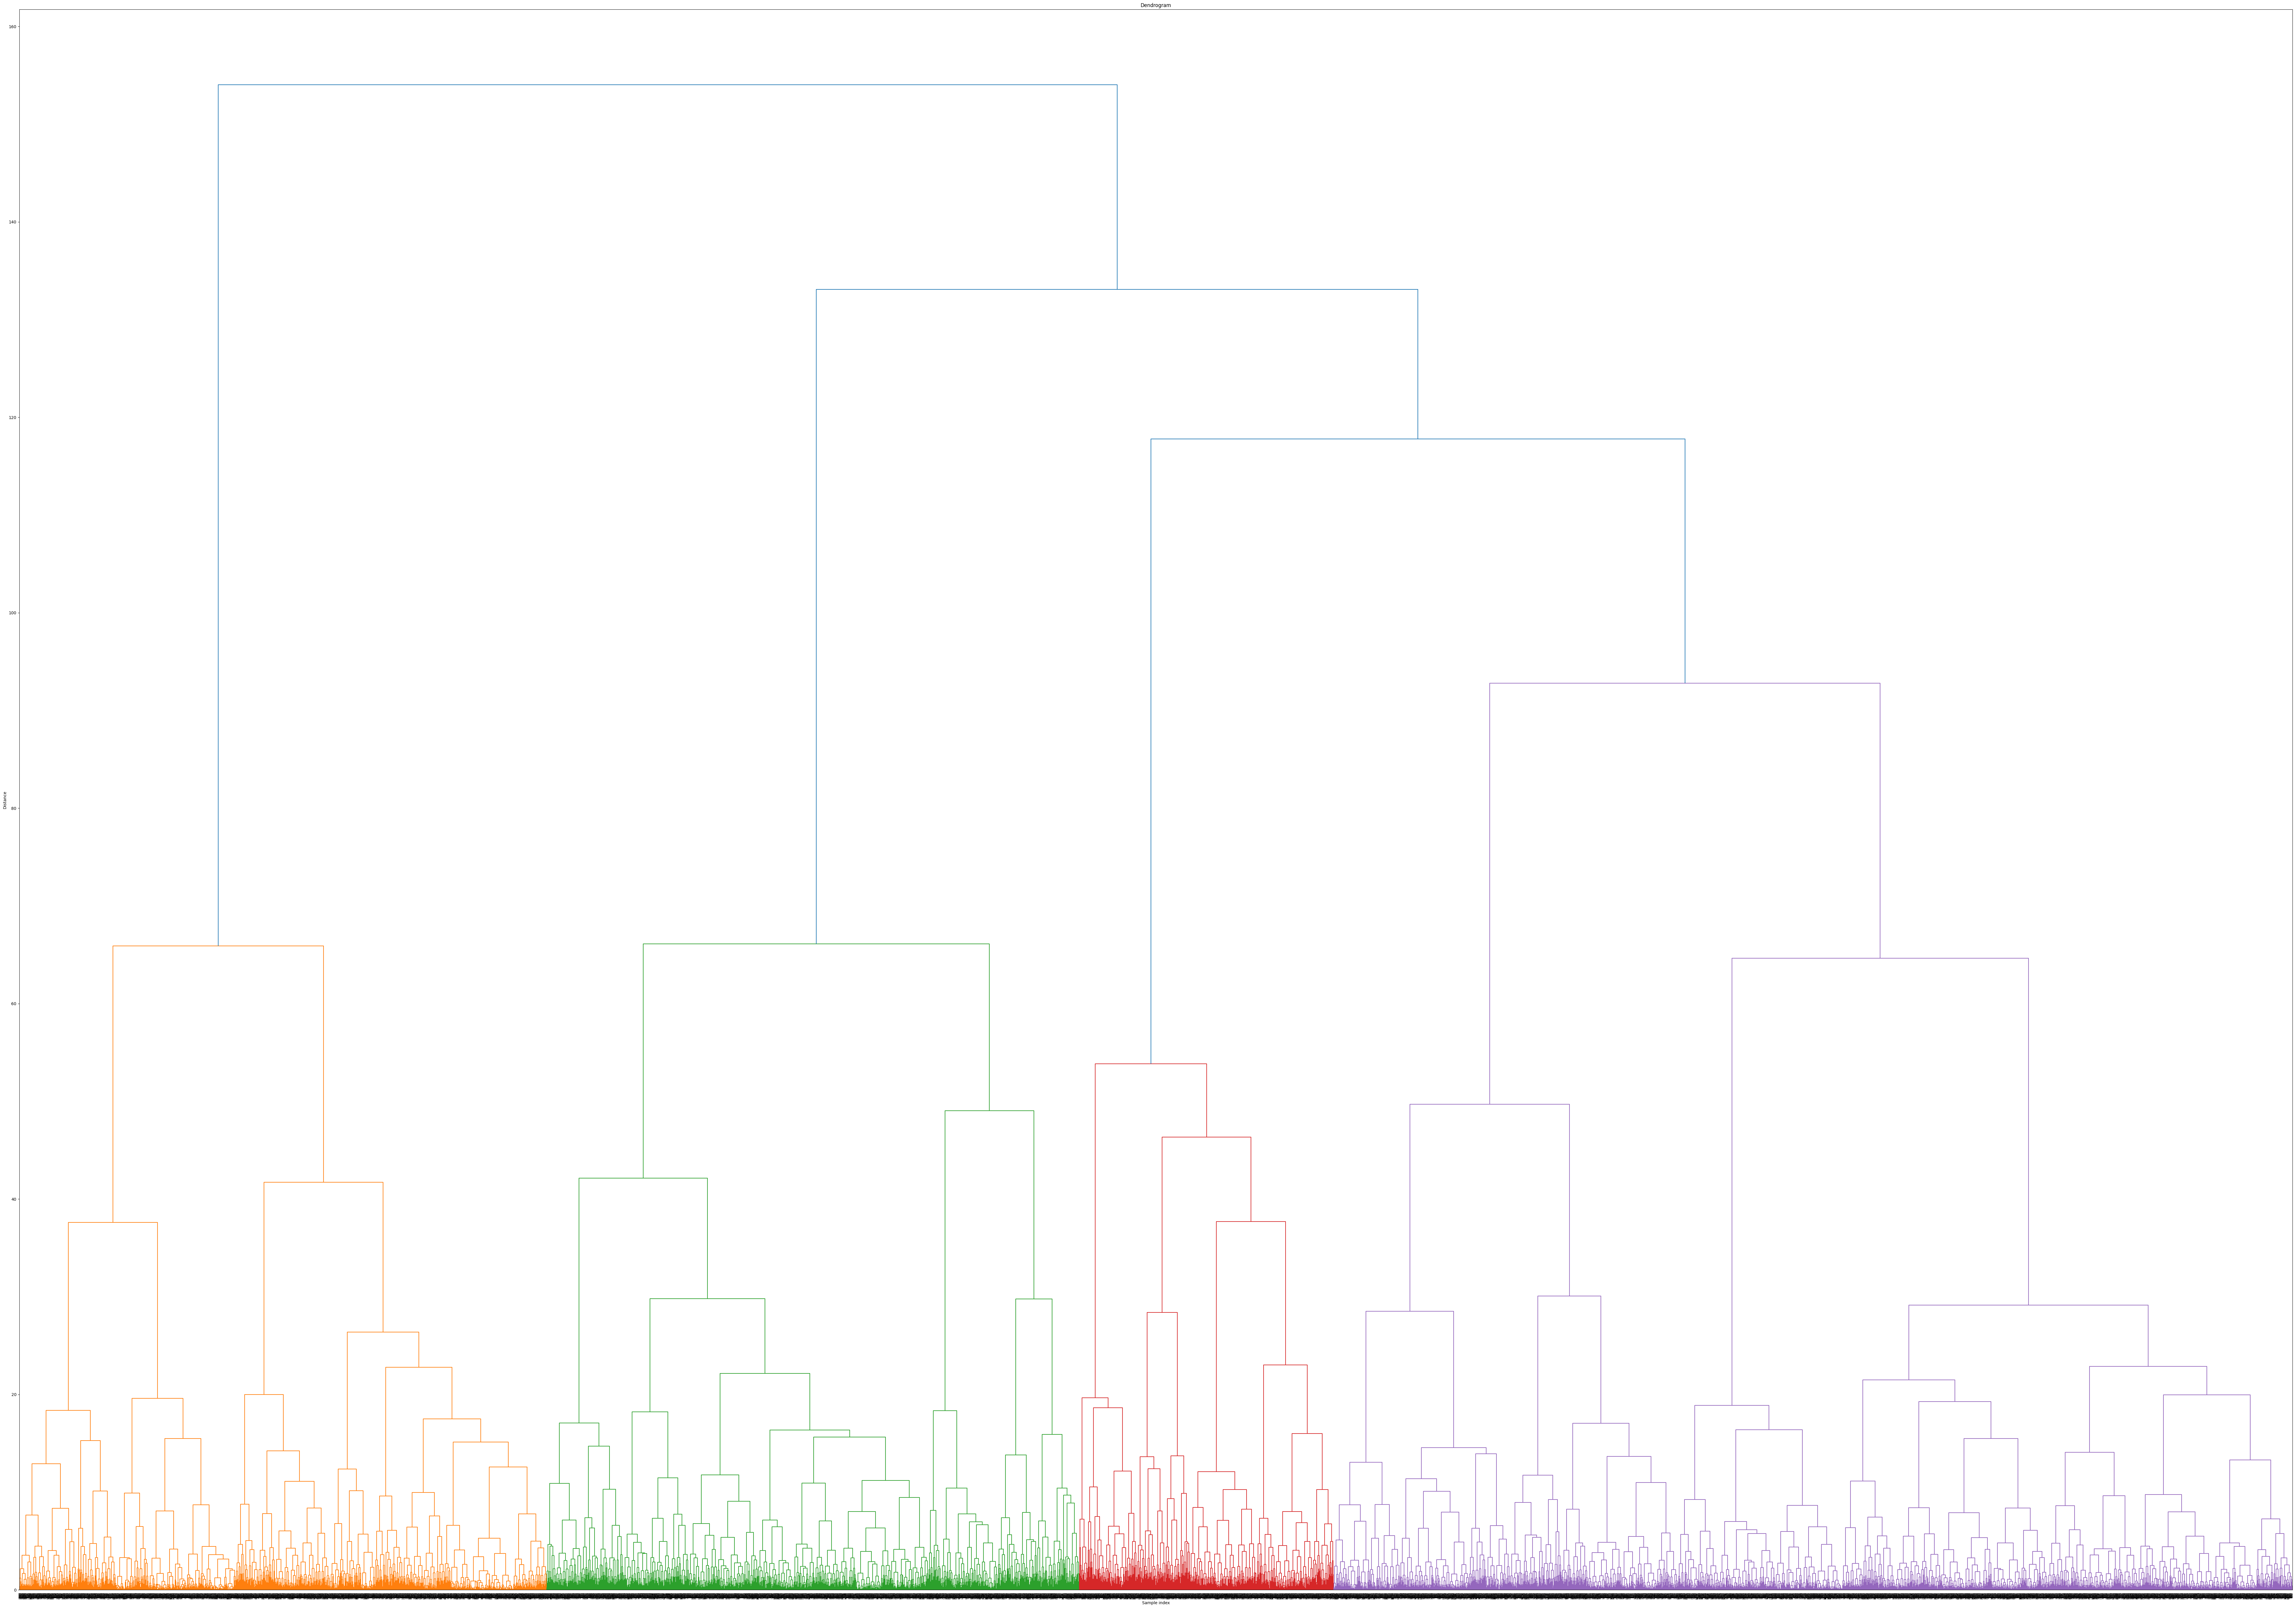

In [ ]:
#import library
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute the linkage matrix

Z = linkage(X_scaled_df, 'ward')

# Plot the dendrogram

plt.figure(figsize=(100, 70))

plt.title("Dendrogram")

plt.xlabel("Sample index")

plt.ylabel("Distance")

dendrogram(Z)

plt.show()

### II. Perform AgglomerativeClustering with 2 clusters, using Euclidean distance for affinity and linkage = 'ward'.

In [ ]:
#from the website blog
#import library
from sklearn.cluster import AgglomerativeClustering

#linkage
# cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
cluster = AgglomerativeClustering(n_clusters=2, linkage='ward') #affinity='euclidean' is there by default. specifying like this doesn't work anymore, it throws an error so had to drop the attribute.

#save the predicted data
cluster_agglo_labels = cluster.fit_predict(X_scaled_df)

#make a copy just in case
df_copy = df.copy()

df_copy['Agglo_clustering'] = cluster_agglo_labels

### III. Plot training hours against experience as in C.XIII. In a markdown cell, discuss anything interesting.

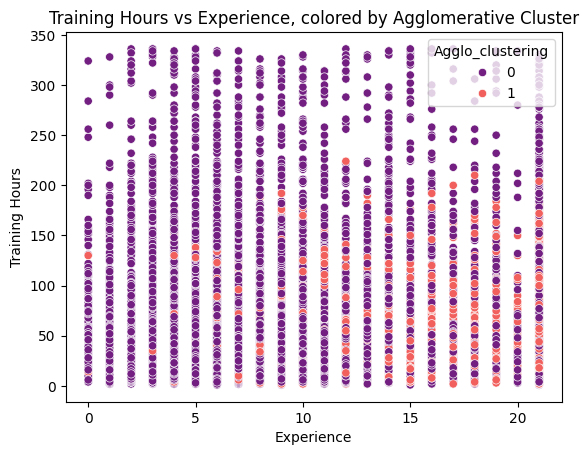

In [ ]:
# plt.scatter(df_copy['experience'], df_copy['training_hours'], c=df_copy['Agglo_clustering'], hue="cluster_label")
sns.scatterplot(data=df_copy, x="experience", y="training_hours", hue="Agglo_clustering", palette="magma")
plt.xlabel('Experience')
plt.ylabel('Training Hours')
plt.title('Training Hours vs Experience, colored by Agglomerative Cluster')
plt.show()

Here comapered to CXIII, majority of the employess are grouped in cluster 0. There also some overlapping between the two clusters due to other attributes.

The plot looks separated and there a separation of the cluster 0 and 1 at around experience years 10 to 13 years and lower training hours. This is roughly the same split that we observed in CXIII at around experience 10 to 13 years. This shows that the split is consistent and strong for two different algorithms showing roughly the same split area. This shows a strong pattern in our data.

### IV. Increase the number of clusters to 4 or 5, build the clusters again, and plot them again. In a markdown cell, discuss any differences you observe.

In [ ]:
#build again with cluster increased to 5

cluster_5 = AgglomerativeClustering(n_clusters=5, linkage='ward') #affinity='euclidean' is there by default. specifying like this doesn't work anymore, it throws an error so had to drop the attribute.

#save the predicted data
cluster_agglo_labels_5 = cluster_5.fit_predict(X_scaled_df)

#make a copy just in case
# df_copy = df.copy()

df_copy['Agglo_clustering_5'] = cluster_agglo_labels_5

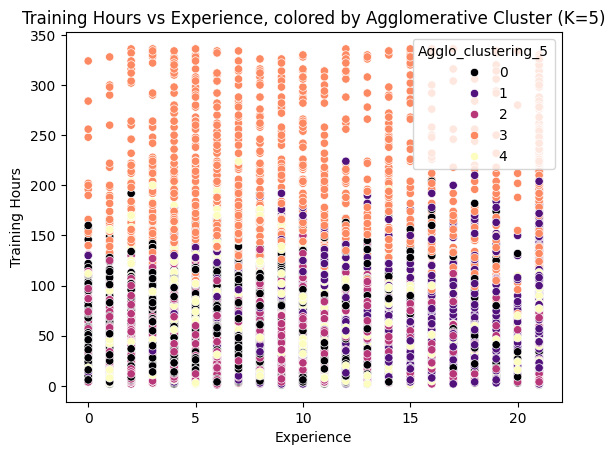

In [ ]:
# plt.scatter(df_copy['experience'], df_copy['training_hours'], c=df_copy['Agglo_clustering_5'])
sns.scatterplot(data=df_copy, x="experience", y="training_hours", hue="Agglo_clustering_5", palette="magma")
plt.xlabel('Experience')
plt.ylabel('Training Hours')
plt.title('Training Hours vs Experience, colored by Agglomerative Cluster (K=5)')
plt.show()

Now I can visualiise an additional value that was not visible earlier in CXIII and where DIII where we only talked about the split 2 cluster split. It reveals other categories to be taken into consideration.

By increasing the cluster value, we can observe that at around training hours > 200, majority of the clusters grouped to cluster 3. This shows that higher taining hours is a dominiting feature and those candidates with greater trainig hours fall into one group. The algorithm was able to isolate the data into other new distinct group like cluster 0, 1, 2 and 4 with a higher k value. There are a lot overlapping among these cluster 0, 1, 2 and 4.

We need to investigate other features as well to distinguish how the clusters are formed based on other features.